# Import Libraries

In [57]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\BankChurners.csv\BankChurners.csv")

df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


# Shape

In [3]:
print(df.shape)

(10127, 23)


# Basic Info

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

# Missing Values

In [5]:
df.isnull().sum()

CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category                                 

# Duplicate Check

In [6]:
df.duplicated().sum()

np.int64(0)

# Drop Unwanted Columns

In [7]:
df.drop([
'CLIENTNUM',

'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',

'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'

],axis=1,inplace=True)

# Target Distribution

In [8]:
df["Attrition_Flag"].value_counts()

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

# Encode Target

In [9]:
df["Attrition_Flag"] = df["Attrition_Flag"].map({
'Existing Customer':0,
'Attrited Customer':1
})

 # EDA - Churn Distribution

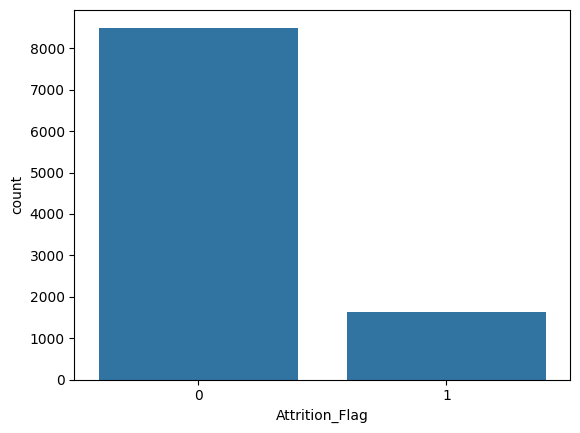

In [10]:
sns.countplot(
x='Attrition_Flag',
data=df
)

plt.show()

# Insight

Customers retained > customers churned.

# Gender vs Churn

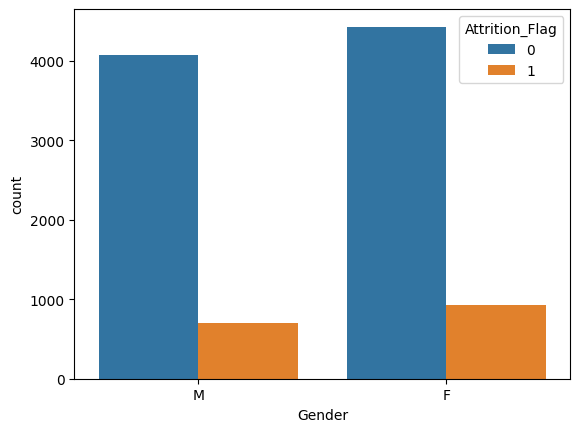

In [11]:
sns.countplot(
x='Gender',
hue='Attrition_Flag',
data=df
)

plt.show()

# Income Category vs Churn

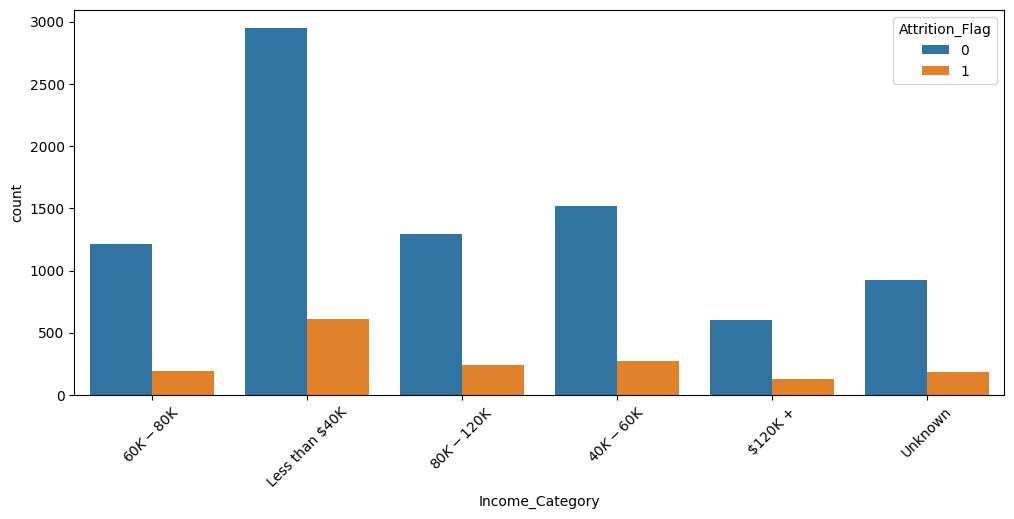

In [12]:
plt.figure(figsize=(12,5))

sns.countplot(
x='Income_Category',
hue='Attrition_Flag',
data=df
)

plt.xticks(rotation=45)

plt.show()

# Card Category

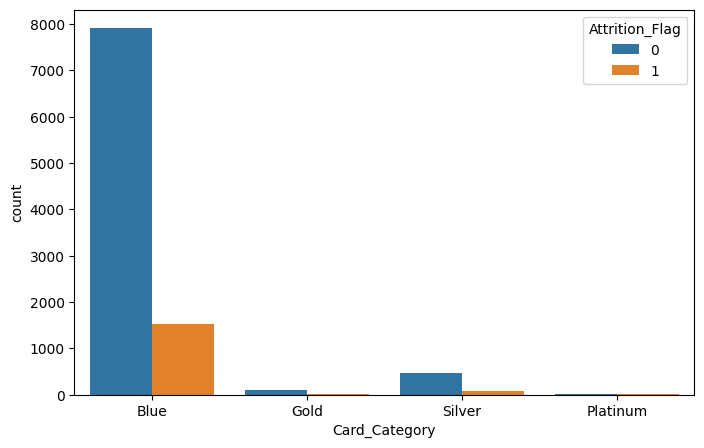

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
x='Card_Category',
hue='Attrition_Flag',
data=df
)

plt.show()

# Transaction Amount

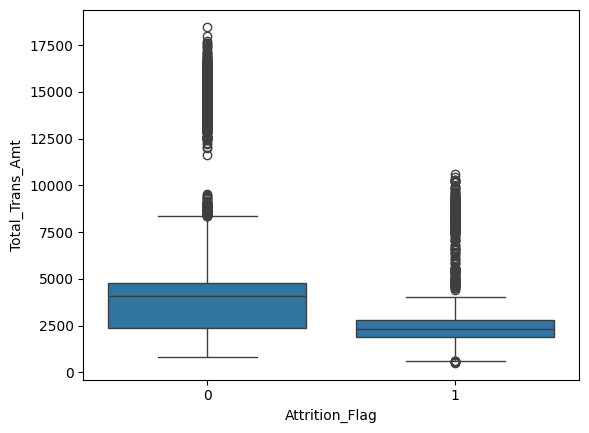

In [14]:
sns.boxplot(
x='Attrition_Flag',
y='Total_Trans_Amt',
data=df
)

plt.show()

# Transaction Count

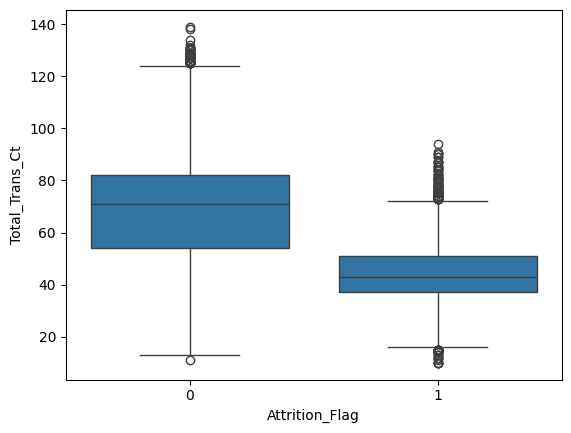

In [15]:
sns.boxplot(
x='Attrition_Flag',
y='Total_Trans_Ct',
data=df
)

plt.show()

 # Correlation Heatmap

In [16]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

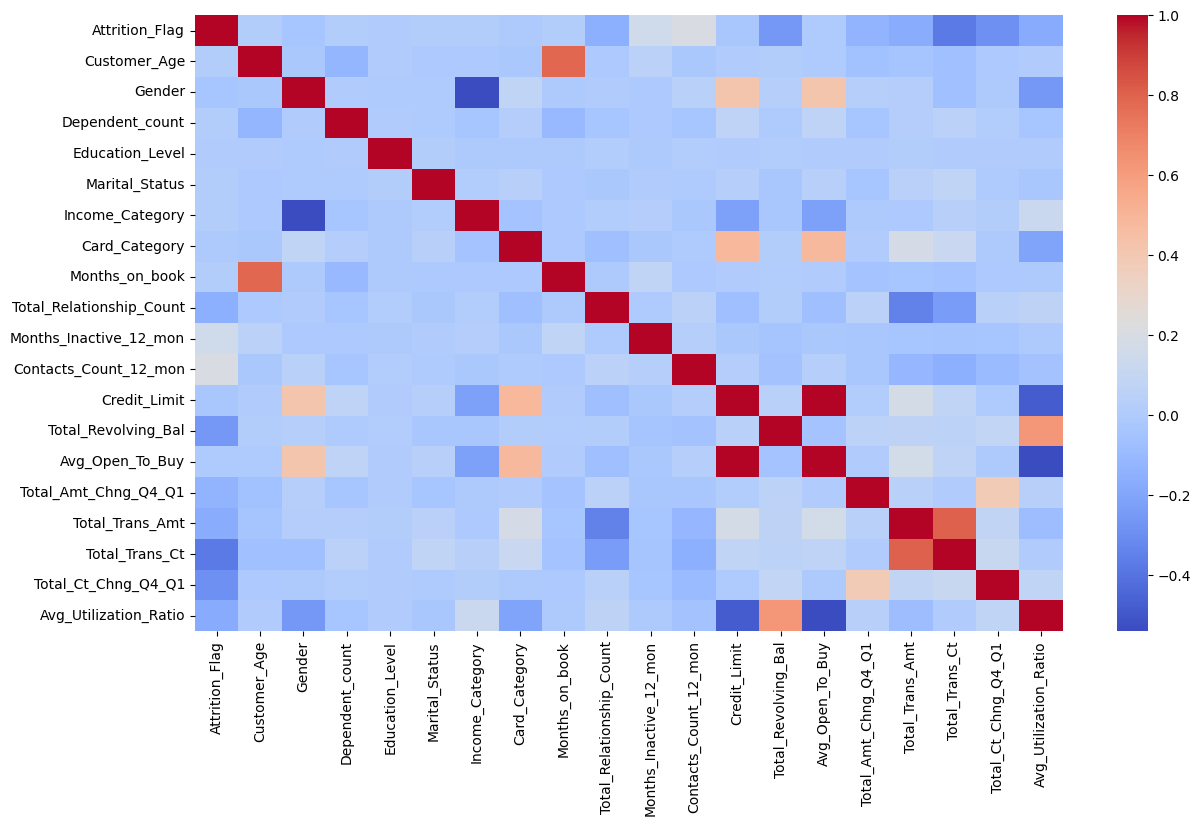

In [17]:
plt.figure(figsize=(14,8))

sns.heatmap(
df.corr(),
cmap='coolwarm'
)

plt.show()

# Feature Engineering

In [38]:
# Top important features only

features = [

'Customer_Age',

'Months_Inactive_12_mon',

'Credit_Limit',

'Total_Trans_Amt',

'Total_Trans_Ct'

]

X = df[features]

y = df['Attrition_Flag']

# Train-test-split

In [39]:
X_train,X_test,y_train,y_test = train_test_split(

X,
y,

test_size=0.2,

random_state=42

)

# SMOTE

In [67]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_smote.value_counts())

Before SMOTE
Attrition_Flag
0    6801
1    1300
Name: count, dtype: int64

After SMOTE
Attrition_Flag
0    6801
1    6801
Name: count, dtype: int64


# Model 1

Logistic Regression

In [69]:
lr = LogisticRegression(
max_iter=5000
)

lr.fit(
X_train_smote,
y_train_smote
)

pred_lr = lr.predict(X_test)
lr.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


# Evaluation

In [73]:
accuracy_score(
y_test,
pred_lr
)

0.7714708785784797

In [74]:
print(
classification_report(
y_test,
pred_lr
)
)

              precision    recall  f1-score   support

           0       0.96      0.76      0.85      1699
           1       0.40      0.82      0.54       327

    accuracy                           0.77      2026
   macro avg       0.68      0.79      0.69      2026
weighted avg       0.87      0.77      0.80      2026



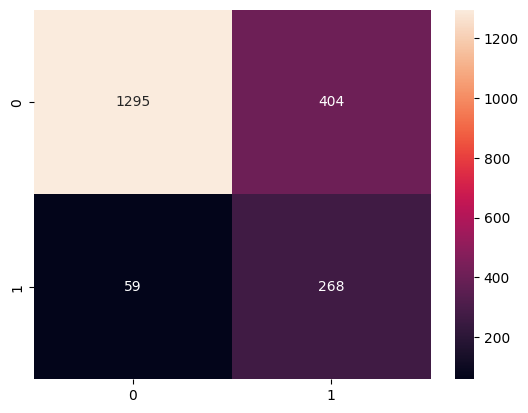

In [75]:
cm = confusion_matrix(
y_test,
pred_lr
)

sns.heatmap(
cm,
annot=True,
fmt='d'
)

plt.show()

# ROC AUC 

In [76]:
from sklearn.metrics import roc_auc_score

prob = lr.predict_proba(X_test)[:,1]

roc_auc_score(
y_test,
prob
)

0.8360053494320279

# Model 2

Random Forest

In [77]:
rf = RandomForestClassifier(

n_estimators=300,

random_state=42

)

rf.fit(
X_train_smote,
y_train_smote
)

pred_rf = rf.predict(X_test)

rf.fit(X_train_smote,y_train_smote)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Accuracy

In [78]:
accuracy_score(
y_test,
pred_rf
)

0.9131293188548865

In [79]:
print(
classification_report(
y_test,
pred_rf
)
)

              precision    recall  f1-score   support

           0       0.96      0.93      0.95      1699
           1       0.70      0.81      0.75       327

    accuracy                           0.91      2026
   macro avg       0.83      0.87      0.85      2026
weighted avg       0.92      0.91      0.92      2026



# Report

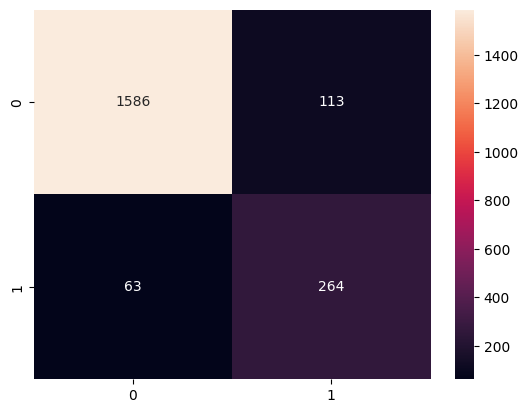

In [80]:
cm = confusion_matrix(
y_test,
pred_rf
)

sns.heatmap(
cm,
annot=True,
fmt='d'
)

plt.show()

# ROC AUC

In [81]:
from sklearn.metrics import roc_auc_score

prob = rf.predict_proba(X_test)[:,1]

roc_auc_score(
y_test,
prob
)

0.9535344590179867

In [84]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)

pred_xgb = xgb.predict(X_test)

# Accuracy

In [85]:
accuracy_score(
y_test,
pred_xgb
)

0.9091806515301086

In [86]:
print(
classification_report(
y_test,
pred_xgb
)
)

              precision    recall  f1-score   support

           0       0.97      0.92      0.94      1699
           1       0.67      0.84      0.75       327

    accuracy                           0.91      2026
   macro avg       0.82      0.88      0.85      2026
weighted avg       0.92      0.91      0.91      2026



# Report

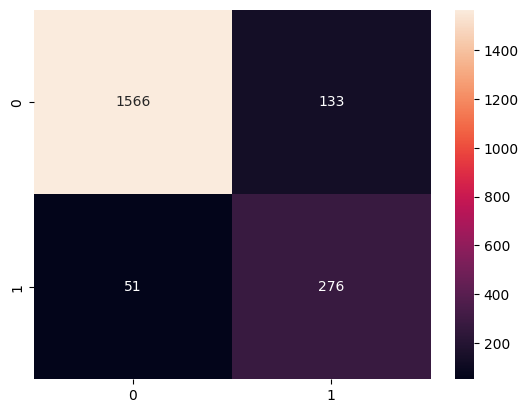

In [87]:
cm = confusion_matrix(
y_test,
pred_xgb
)

sns.heatmap(
cm,
annot=True,
fmt='d'
)

plt.show()

# ROC-AUC

In [88]:
from sklearn.metrics import roc_auc_score

prob = rf.predict_proba(X_test)[:,1]

roc_auc_score(
y_test,
prob
)

0.9535344590179867

# Feature Importance

In [92]:
importance = pd.DataFrame({

"Feature":X.columns,

"Importance":rf.feature_importances_

})

In [93]:
importance.sort_values(

by="Importance",

ascending=False

).head(10)

,Feature,Importance
3,Total_Trans_Amt,0.394852
4,Total_Trans_Ct,0.358268
2,Credit_Limit,0.111184
0,Customer_Age,0.088192
1,Months_Inactive_12_mon,0.047504


# Visualization

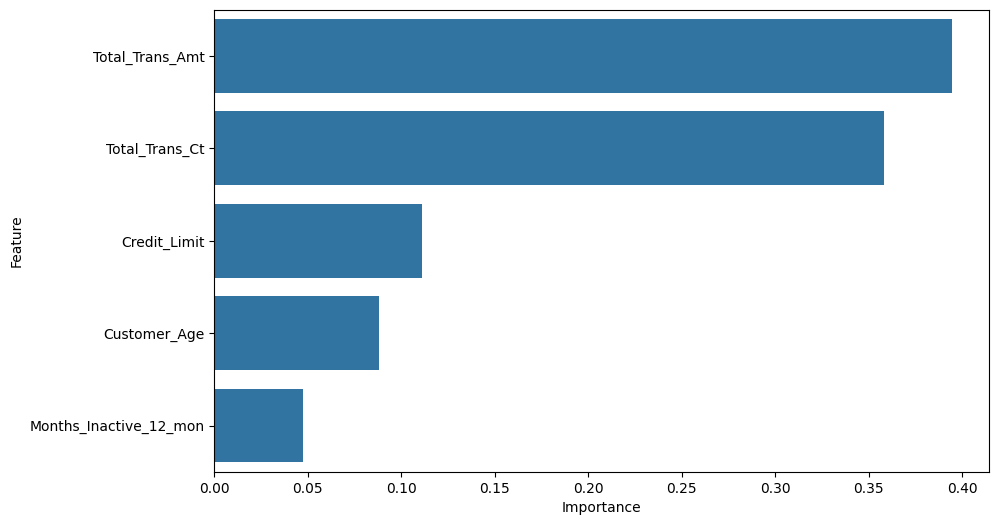

In [94]:
top = importance.sort_values(

by="Importance",

ascending=False

).head(10)

plt.figure(figsize=(10,6))

sns.barplot(

x='Importance',

y='Feature',

data=top

)

plt.show()

# Save Model

In [96]:
import pickle

pickle.dump(
rf,
open(
"churn_model.pkl",
"wb"
)
)

# Business Insights

Finding 1

Customers with lower transaction count have higher churn probability.

Finding 2

Customers with higher inactivity months are more likely to leave.

Finding 3

Blue card customers show greater churn risk.

Finding 4

Customer engagement directly impacts retention.

# Business Recommendations

1.Loyalty rewards for low-transaction customers.

2.Re-engage inactive customers.

3.Personalized offers.

4.Early churn warning system.